# **Comparação e Seleção de Modelos**
<font size=3>

Até este momento do curso, nosso foco esteve no treinamento de algoritmos capazes de aprender padrões. No entanto, ao nos depararmos com dois modelos concorrentes — por exemplo, um com 94% de acurácia e outro com 94.5% — surge uma questão crítica: **essa superioridade numérica é real ou apenas resultado da aleatoriedade na divisão dos dados?** Nesta aula, avançaremos da simples observação de métricas médias para a **avaliação estatística rigorosa**. Utilizaremos testes de hipótese para distinguir melhorias significativas de flutuações ao acaso. Além disso, aprofundaremos nossa análise com a **Decomposição Viés-Variância**, uma ferramenta diagnóstica fundamental para entender não apenas *quanto* um modelo erra, mas *por que* ele erra, permitindo escolhas mais seguras e robustas para ambientes de produção.


## **1. Testes de Hipótese:**
<font size=3>

Ao avaliar modelos preditivos, não basta observar diferenças numéricas em métricas como acurácia, precisão ou erro médio. Essas diferenças podem ser resultado de variações aleatórias nos dados. Por isso, utilizamos **testes de hipótese estatísticos** para verificar se as diferenças de desempenho entre modelos são **estatisticamente significativas**, ou seja, improváveis de ocorrerem por mero acaso.

### **1.1 Comparando dois modelos:**
<font size=3>

Quando temos **dois modelos preditivos** avaliados nas **mesmas partições de dados**, como em uma validação cruzada, podemos aplicar testes estatísticos para verificar se existe uma diferença real entre seus desempenhos médios.


#### **1.1.1 Teste t Pareado Corrigido:**
<font size=3>
    
Para comparar estatisticamente o desempenho de dois classificadores ($M_1$ e $M_2$) avaliados sob o mesmo esquema de validação cruzada ($K$-Fold CV), utilizamos o **Teste t Pareado Corrigido**. Este teste foi formalmente projetado para contornar os desafios probabilísticos intrínsecos à estrutura da validação cruzada em Aprendizado de Máquina.

Assim, seja $x_{1,i}$ o desempenho do modelo $M_1$ no *fold* $i$ e $x_{2,i}$ o desempenho do modelo $M_2$ no mesmo *fold* $i$, para $i = 1, 2, \dots, n$.

1. **Diferença pareada:**
Calculamos a diferença de desempenho para cada partição:
$$
    D_i = x_{1,i} - x_{2,i}
$$

2. **Média amostral das diferenças ($\bar{D}$):**
$$
    \bar{D} = \frac{1}{n} \sum_{i=1}^{n} D_i
$$

3. **Variância amostral modificada ($s_D^2$):**
$$
    s_D^2 = \frac{1}{n-1} \sum_{i=1}^{n} (D_i - \bar{D})^2
$$

4. **Estatística de teste corrigida ($t$):**
O denominador incorpora matematicamente a razão entre o tamanho do conjunto de teste ($n_{\text{teste}}$) e o do conjunto de treino ($n_{\text{treino}}$), corrigindo o viés de sobreposição dos dados:
$$
    t = \frac{\bar{D}}{\sqrt{\left(\frac{1}{n} + \frac{n_{\text{teste}}}{n_{\text{treino}}}\right) s_D^2}}
$$

> **Observação:** Este é um teste *paramétrico* — ele assume que a diferença entre os desempenhos dos pares sigam uma **distribuição normal**.


<font size=3>

**Formulação das Hipóteses:**

Para validar matematicamente a comparação, definimos as seguintes hipóteses:

* **Hipótese Nula ($H_0$):** $\mu_D = 0$ (Não há diferença real entre o desempenho dos modelos).
* **Hipótese Alternativa ($H_1$):** $\mu_D \neq 0$ (Existe uma diferença significativa de desempenho).

Antes de computar os dados, fixamos um nível de significância $\alpha$ (geralmente $0.05$ ou $5\%$). Este limiar estabelece as fronteiras da **Zona de Rejeição**. Como avaliamos se um modelo é simplesmente *diferente* do outro (podendo ser superior ou inferior), o teste é **bicaudal**, dividindo a Zona de Rejeição igualmente entre as duas extremidades da distribuição ($2.5\%$ em cada cauda).

* **Zona de Rejeição:** Corresponde às áreas extremas da curva onde os valores de $t$ são tão atípicos que se torna altamente improvável que tenham ocorrido sob a vigência do acaso. Se o nosso $t$ calculado cair nesta região, rejeitamos a hipótese nula ($H_0$).

* **p-valor (valor de probabilidade):** É a probabilidade exata de obtermos uma estatística de teste tão extrema ou mais extrema do que o nosso $t$ observado, assumindo $H_0$ como verdadeira.

Matematicamente, a expressão analítica que vincula a estatística $t$ ao p-valor em um teste bicaudal baseia-se na *função de distribuição acumulada* $F_T$ da [distribuição *t de Student*](https://pt.wikipedia.org/wiki/Distribui%C3%A7%C3%A3o_t_de_Student),
$$
    \text{p-valor} = 2 \left(1 - F_T(|t|)\right) \, .
$$

Geometricamente, o *p-valor representa a soma das áreas sob a curva* que partem de $|t|$ e $-|t|$ em direção às caudas infinitas. Se o $t$ calculado ultrapassar os limites críticos da **Zona de Rejeição**, a área correspondente ao p-valor será menor que $\alpha$ ($\text{p-valor} \le 0.05$), confirmando a separação estatística dos modelos.

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from sklearn.datasets import make_classification
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

In [5]:
# simulando dados para classificação:
X, y = make_classification(n_samples=1000, n_classes=2, weights=[0.7, 0.3], flip_y=0.1, random_state=42)

# definindo os modelos:
model_a = RandomForestClassifier(n_estimators=10, random_state=42)
model_b = SVC(kernel='linear')

# avaliação com validação cruzada (10 folds):
k_folds = 10

scores_a = cross_val_score(model_a, X, y, cv=k_folds, scoring="accuracy")
scores_b = cross_val_score(model_b, X, y, cv=k_folds, scoring="accuracy")

print("Acurácias Modelo A (RF): ", scores_a)
print("Acurácias Modelo B (SVC):", scores_b)

print(f"\nMédia A: {np.mean(scores_a):.3f} | Média B: {np.mean(scores_b):.3f}")

Acurácias Modelo A (RF):  [0.83 0.86 0.91 0.83 0.93 0.88 0.84 0.86 0.89 0.92]
Acurácias Modelo B (SVC): [0.85 0.84 0.89 0.82 0.87 0.83 0.83 0.87 0.87 0.88]

Média A: 0.875 | Média B: 0.855


In [6]:
# calculando a estatística t corrigida:
D = scores_a - scores_b
mean_D = np.mean(D)

var_D = np.var(D, ddof=1)

t_stat = mean_D/np.sqrt(((1/k_folds) + 1/(k_folds - 1))*var_D)

# calculando o p-valor:
df = k_folds - 1
α = 0.05

p_value = 2*(1 - stats.t.cdf(np.abs(t_stat), df=df))
t_critic = stats.t.ppf(1 - α/2, df)

print(f"Estatística t calculada real: {t_stat:.4f}")
print(f"Fronteira da Zona de Rejeição (|t| > t_crit): {t_critic:.4f}")
print(f"p-valor bicaudal mensurado: {p_value:.4f}\n")

if p_value < α:
    print(f"RESULTADO: p-valor ({p_value:.4f}) <= α ({α}). Rejeita-se H0.")
    print("Conclusão: Existe uma diferença estatisticamente significativa entre os algoritmos nas partições do dataset avaliado.")
else:
    print(f"RESULTADO: p-valor ({p_value:.4f}) > α ({α}). Falha em rejeitar H0.")
    print("Conclusão: Não há evidência estatística de que um algoritmo supere o outro neste dataset.")


Estatística t calculada real: 1.7450
Fronteira da Zona de Rejeição (|t| > t_crit): 2.2622
p-valor bicaudal mensurado: 0.1149

RESULTADO: p-valor (0.1149) > α (0.05). Falha em rejeitar H0.
Conclusão: Não há evidência estatística de que um algoritmo supere o outro neste dataset.


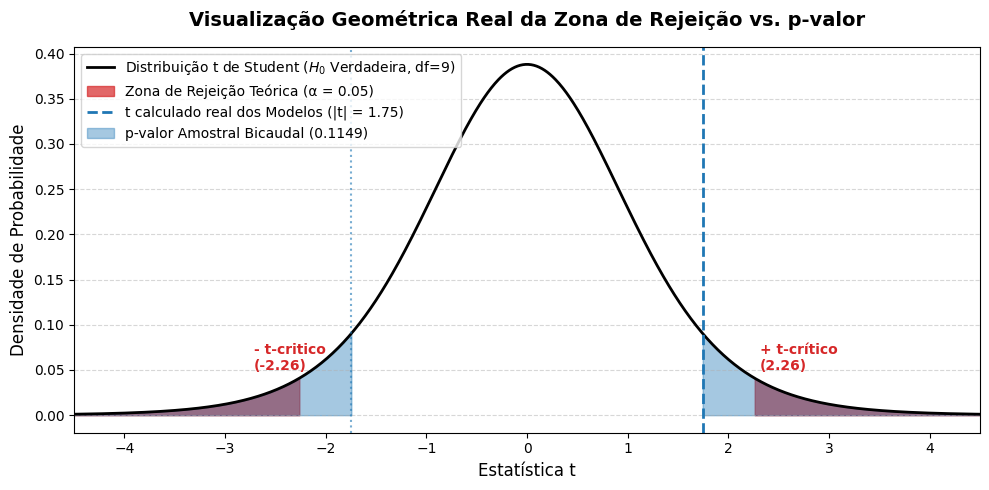

In [7]:
# plotando a densidade de probabilidade da distribuição t:
x_lim = max(4.5, np.abs(t_stat) + 1.0)
x = np.linspace(-x_lim, x_lim, 1000)
y = stats.t.pdf(x, df)

plt.figure(figsize=(10, 5))
plt.plot(x, y, color='black', linewidth=2, label=f"Distribuição t de Student ($H_0$ Verdadeira, df={df})")

# pintando a zona de rejeição baseada no α (2.5% em cada cauda):
x_crit_esq = np.linspace(-x_lim, -t_critic, 100)
x_crit_dir = np.linspace(t_critic, x_lim, 100)
plt.fill_between(x_crit_esq, stats.t.pdf(x_crit_esq, df), color='tab:red', alpha=0.7, label=f'Zona de Rejeição Teórica (α = {α:.2f})')
plt.fill_between(x_crit_dir, stats.t.pdf(x_crit_dir, df), color='tab:red', alpha=0.7)

# plotando as linhas verticais do t REAL obtido na comparação dos modelos:
plt.axvline(t_stat, color='tab:blue', linestyle='--', linewidth=2, label=f't calculado real dos Modelos (|t| = {t_stat:.2f})')
plt.axvline(-t_stat, color='tab:blue', linestyle=':', linewidth=1.5, alpha=0.6)

# pintando a área exata do p-valor amostral real obtido nas duas caudas:
x_p_esq = np.linspace(-x_lim, -np.abs(t_stat), 100)
x_p_dir = np.linspace(np.abs(t_stat), x_lim, 100)
plt.fill_between(x_p_esq, stats.t.pdf(x_p_esq, df), color='tab:blue', alpha=0.4, label=f'p-valor Amostral Bicaudal ({p_value:.4f})')
plt.fill_between(x_p_dir, stats.t.pdf(x_p_dir, df), color='tab:blue', alpha=0.4)

plt.title("Visualização Geométrica Real da Zona de Rejeição vs. p-valor", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Estatística t", fontsize=12)
plt.ylabel("Densidade de Probabilidade", fontsize=12)
plt.xlim(-x_lim, x_lim)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.text(t_critic+0.05, 0.05, f'+ t-crítico\n({t_critic:.2f})', color='tab:red', fontsize=10, fontweight='bold')
plt.text(-t_critic-0.45, 0.05, f'- t-critico\n({-t_critic:.2f})', color='tab:red', fontsize=10, fontweight='bold')

plt.legend(loc='upper left', fontsize=10)
plt.tight_layout()
plt.show()

<font size=3>
    
Olhando puramente para os dados descritivos, o **modelo A (Random Forest)** obteve uma acurácia média de $87.5\%$, enquanto o **modelo B (SVC)** obteve $85.5\%$. Nominalmente, o Random Forest é $2.0\%$ superior. No entanto, para validar se essa diferença reflete uma disparidade na média populacional ($\mu_D \neq 0$), submetemos os dados ao Teste t Pareado Corrigido sob um nível de significância de $\alpha = 0.05$:

* **Critério da Zona de Rejeição:** A fronteira crítica calculada para a distribuição $t$ com 9 graus de liberdade é de $t_{\text{crit}} = \pm 2.2622$. A nossa estatística $t$ calculada real foi de **$1.7450$**. Como $|1.7450| < 2.2622$, a estatística estatística **não alcançou a Zona de Rejeição**, situando-se na região de alta probabilidade da hipótese nula ($H_0$).

* **Critério do p-valor:** O p-valor bicaudal mensurado foi de $11.49\%$. Como $\text{p-valor} > \alpha$, falhamos em rejeitar a hipótese nula.

Dizer que o p-valor é $0.1149$ significa:
> Se o Random Forest e o SVC tivessem exatamente o mesmo desempenho no universo real ($H_0$ verdadeira), a chance de obtermos uma diferença de acurácia de $2.0\%$ (ou mais) apenas por pura sorte ou aleatoriedade na divisão dos 10 folds é de **$11.49\%$**.

Como essa probabilidade é substancialmente maior do que o nosso limite de tolerância ao erro ($5\%$), não podemos descartar a hipótese de que a aparente vantagem do Random Forest seja apenas ruído amostral. No entanto, do ponto de vista científico e de negócios, **os dois modelos devem ser considerados estatisticamente equivalentes** para este problema, já que a vantagem de $2\%$ do Random Forest não foi comprovada. Agora, considerando a implantação em produção, o SVC *linear* **deve ser o modelo escolhido**, por se tratar de um modelo com menor complexidade em tempo e espaço que o Random Forest, neste caso.


#### **1.1.2 Teste de Wilcoxon:**
<font size=3>
    
O Teste t de Student baseia-se na suposição de que as diferenças observadas seguem uma distribuição normal. No entanto, em cenários reais de Aprendizado de Máquina, frequentemente nos deparamos com distribuições fortemente assimétricas, com caudas longas ou presença de *outliers*.

Quando a premissa de normalidade é violada, os testes paramétricos perdem robustez e poder estatístico. É aqui que entra o **Teste de Wilcoxon**, uma alternativa **não-paramétrica** clássica. Em vez de avaliar os valores numéricos brutos das métricas e suas médias, este teste opera sobre a **ordem de grandeza** das diferenças, isto é, sobre os seus **_ranks_**.

> **Observação:** a aplicação da teste de Wilcoxon sobre *folds* de um único *dataset* (como fizemos no Teste t), pode acarretar viés de sobreposição dos resultados. Para uma estatística mais precisa, recomenda-se comparar o desempenho de algoritmos ao longo de **múltiplos conjuntos de dados independentes**.


<font size=3>

Seja $x_{1,i}$ o desempenho do modelo $M_1$ e $x_{2,i}$ o desempenho do modelo $M_2$ mensurados no conjunto de dados (ou partição) $i$, para $i = 1, 2, \dots, N$.

1. **Cálculo das diferenças brutas:**
$$
    D_i = x_{1,i} - x_{2,i}
$$

2. **Filtragem de empates:**
Removem-se todas as ocorrências onde $D_i = 0$. Seja $n$ o número restante de diferenças não-nulas ($n \le N$).

3. **Atribuição de *ranking*:**
Ordenam-se os valores **absolutos** das diferenças, $|D_i|$, do menor para o maior. Atribuem-se *ranks* de $1$ (para a menor diferença absoluta) até $n$ (para a maior). Se houver empates nos valores absolutos, atribui-se a média dos *ranks* que seriam ocupados por esses valores.

4. **Separação dos sinais e estatística do teste ($W$):**
Calcula-se a soma dos *ranks* das diferenças que eram originalmente positivas ($W^+$) e das diferenças que eram originalmente negativas ($W^-$):
\begin{align}
    W^+ &= \sum_{i: D_i > 0} \text{Rank}(|D_i|) \\
    W^- &= \sum_{i: D_i < 0} \text{Rank}(|D_i|)
\end{align}

A estatística final do teste de Wilcoxon, denotada por $W$, é o **menor** valor entre essas duas somas:
$$
    W = \min(W^+, W^-)
$$

>**Observação:**
>* No teste $t$, quanto **maior** for o valor de $|t|$, mais distante estamos do acaso e mais propensos a rejeitar $H_0$.
>* No teste de Wilcoxon, a lógica é **inversa**. Se a hipótese nula ($H_0$) for verdadeira (modelos idênticos), as somas $W^+$ e $W^-$ tendem a ser muito parecidas, fazendo com que $W$ assuma um valor alto.
>* Por outro lado, se um modelo for consistentemente superior ao outro, quase todas as diferenças terão o mesmo sinal. Isso jogará uma das somas ($W^+$ ou $W^-$) para perto de zero. Portanto, **valores muito pequenos de $W$ indicam assimetria total e nos levam a entrar na Zona de Rejeição**.


<font size=3>

Quando o número de amostras ou datasets é pequeno, a distribuição de $W$ sob a hipótese nula ($H_0$) é determinada de forma puramente **combinatória**.

Sob a hipótese nula ($H_0$), assume-se que os dois modelos comparados possuem desempenhos equivalentes. Isso significa que, para qualquer par analisado, a diferença de desempenho ($D_i$) tem a mesma probabilidade ($50\%$) de ter um sinal positivo ou um sinal negativo.

1. Como temos $n$ *ranks* atribuídos ($1, 2, \dots, n$), existem exatamente **$2^n$ combinações de sinais** possíveis para o conjunto total de *ranks*.

2. Para cada uma dessas $2^n$ combinações hipotéticas, calcula-se o valor que a estatística assumiria, isto é, $W = \min(W^+, W^-)$.

3. Mapeando todas as opções, constrói-se a **distribuição de probabilidade exata** de $W$ sob $H_0$.

O p-valor é definido como a probabilidade de se obter, por mero acaso, uma estatística $W$ **igual ou menor** do que o valor real que você calculou na sua amostra $\left(W_{\text{calc}}\right)$. Como o $W$ já rastreia o menor valor (a cauda inferior), basta calcular a probabilidade acumulada nessa cauda e multiplicá-la por 2 para obter o comportamento bicaudal:
$$
    p\text{-valor} = 2\, \frac{\text{Número de combinações de sinais onde } W \le W_{\text{calc}}}{2^n}
$$


In [8]:
import pandas as pd
from scipy.stats import wilcoxon

In [9]:
# simulando desempenhos médios de 10 datasets independentes:
scores_a = np.array([0.88, 0.92, 0.75, 0.89, 0.94, 0.81, 0.86, 0.90, 0.42, 0.88])
scores_b = np.array([0.85, 0.91, 0.74, 0.86, 0.93, 0.80, 0.85, 0.89, 0.88, 0.85])

datasets = [f"Dataset-{i+1}" for i in range(10)]

df_benchmark = pd.DataFrame({'M1 (Random Forest)':scores_a,
                             'M2 (SVC)':scores_b},
                            index=datasets)

# excutando o cálculo passo a passo:
df_benchmark['Diferença (D_i)'] = df_benchmark['M1 (Random Forest)'] - df_benchmark['M2 (SVC)']
df_benchmark['|D_i|'] = df_benchmark['Diferença (D_i)'].abs()
df_benchmark['Rank (|D_i|)'] = df_benchmark['|D_i|'].rank(method='average')

print("Tabela de evolução dos ranks:")
display(df_benchmark.round(3))

# aplicação do teste de Wilcoxon:
w_stat, p_value = wilcoxon(scores_a, scores_b, alternative='two-sided', mode='exact')

print(f"Estatística W calculada (min(W+, W-)): {w_stat}")
print(f"p-valor: {p_value:.4f}")

if p_value < α:
    print(f"RESULTADO: p-valor ({p_value:.4f}) <= α ({α}). Rejeita-se H0.")
    print("Conclusão: Existe uma diferença estatisticamente significativa entre os algoritmos nos datasets avaliados.")
else:
    print(f"\nRESULTADO: p-valor ({p_value:.4f}) > α ({α}). Falha em rejeitar H0.")
    print("Conclusão: Não há evidência estatística de que um algoritmo supere o outro globalmente.")


Tabela de evolução dos ranks:


,M1 (Random Forest),M2 (SVC),Diferença (D_i),|D_i|,Rank (|D_i|)
Dataset-1,0.88,0.85,0.03,0.03,8.0
Dataset-2,0.92,0.91,0.01,0.01,4.0
Dataset-3,0.75,0.74,0.01,0.01,4.0
Dataset-4,0.89,0.86,0.03,0.03,8.0
Dataset-5,0.94,0.93,0.01,0.01,1.0
Dataset-6,0.81,0.80,0.01,0.01,4.0
Dataset-7,0.86,0.85,0.01,0.01,4.0
Dataset-8,0.90,0.89,0.01,0.01,4.0
Dataset-9,0.42,0.88,-0.46,0.46,10.0
Dataset-10,0.88,0.85,0.03,0.03,8.0


Estatística W calculada (min(W+, W-)): 10.0
p-valor: 0.0840

RESULTADO: p-valor (0.0840) > α (0.05). Falha em rejeitar H0.
Conclusão: Não há evidência estatística de que um algoritmo supere o outro globalmente.


<font size=3>
<br>
    
O teste não-paramétrico de Wilcoxon nos impede de descartar um excelente algoritmo generalista por causa de uma grande falha isolada (como é o caso do Random Forest no Dataset-9) em um ambiente atípico. Ele foca na **consistência da dominância** de um modelo sobre o outro ao longo do ecossistema de dados.

### **1.2 Comparação de múltiplos modelos:**
<font size=3>
    
No cenário anterior, queríamos decidir apenas entre o Modelo A e o Modelo B. Mas e se tivermos **mais de 2 algoritmos** para comparação? Nesta seção iremos explorar:
- Um método para **comparação par a par de modelos** (estatística com correção de Bonferroni);
- Um método para **comparação direta de múltiplos modelos** (teste de Friedman).


#### **1.2.1 Correção de Bonferroni:**
<font size=3>

Se definirmos nosso nível de significância em $\alpha = 0.05$ (aceitando 5% de chance de Falso Positivo), a cada nova comparação que fazemos, essa margem de erro se acumula. Se compararmos 4 modelos, faremos 6 cruzamentos. A chance real de cometermos pelo menos um erro de falso positivo salta de 5% para quase 26%!

Para proteger o nosso experimento, aplicamos a **Correção de Bonferroni**: nós dividimos o nosso $\alpha$ original pelo número total de comparações ($m$) que faremos,
$$
    \alpha_{\text{Bonferroni}} = \frac{2\alpha}{k(k-1)} \, ,
$$
onde $k$ é o número de modelos. Dessa forma, a "régua" para declarar que um modelo é estatisticamente melhor que o outro fica muito mais rigorosa, garantindo que a nossa taxa global de falsos positivos permaneça cravada em 5%.

A correção de Bonferroni é um princípio universal e pode ser aplicada a qualquer teste, seja o **teste $t$ corrigido** (para sobreposição de dados de um K-Fold em um único *dataset*), ou o **teste de Wilcoxon pareado** (para abordagem não-paramétrica considerando diferentes *datasets*).

In [10]:
import seaborn as sns
from scipy import stats
from sklearn.model_selection import KFold
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression

In [11]:
def t_test(scores_A, scores_B, n_splits):

    """Calcula o Teste t pareado corrigido para K-Fold CV"""

    diff = np.array(scores_A) - np.array(scores_B)
    mean_diff = np.mean(diff)
    var_diff = np.var(diff, ddof=1)

    n_test_n_train = (1/n_splits)/((n_splits - 1)/n_splits)

    var_corrigida = var_diff*((1/n_splits) + n_test_n_train)

    if var_corrigida == 0:
        return 0.0, 1.0

    t_stat = mean_diff/np.sqrt(var_corrigida)

    df = n_splits - 1
    p_valor = stats.t.sf(np.abs(t_stat), df)*2

    return t_stat, p_valor


In [12]:
# simulando os dados e definindo os modelos:
X, y = make_classification(n_samples=800, n_features=15, n_informative=8,
                           random_state=42, class_sep=0.8)

models = {'Logistic Reg': LogisticRegression(max_iter=1000),
          'Linear SVC': SVC(kernel='linear', C=1.0),
          'Random Forest': RandomForestClassifier(n_estimators=50, random_state=42),
          'Gradient Boosting': GradientBoostingClassifier(n_estimators=50, random_state=42)}

n_splits = 10
# random_state fixo para garantir que todos os models vejam os mesmos folds
cv_obj = KFold(n_splits=n_splits, shuffle=True, random_state=42)


results_cv = {}
for nome, modelo in models.items():
    scores = cross_val_score(modelo, X, y, cv=cv_obj, scoring='accuracy')
    results_cv[nome] = scores

df_results = pd.DataFrame(results_cv)
df_results

,Logistic Reg,Linear SVC,Random Forest,Gradient Boosting
0,0.6625,0.6625,0.8750,0.8375
1,0.8375,0.8375,0.8625,0.8625
2,0.7125,0.7000,0.8750,0.8875
3,0.7750,0.7750,0.9125,0.9250
4,0.8000,0.8125,0.8750,0.9250
5,0.7750,0.7750,0.8625,0.8375
6,0.7375,0.7625,0.8250,0.8250
7,0.7125,0.7250,0.8875,0.8625
8,0.7125,0.7125,0.8125,0.8000
9,0.7750,0.7500,0.8750,0.8750


In [13]:
# comparação par a par com correção de Bonferroni:

names = list(models.keys())
k_models = len(names)
n_campare = (k_models*(k_models - 1))/2

α_original = 0.05
α_bonferroni = α_original/n_campare

# definindo matrizes para os heatmaps:
matriz_p_t = np.ones((k_models, k_models))
matriz_p_w = np.ones((k_models, k_models))

for i in range(k_models):
    for j in range(k_models):
        if i == j:
            continue

        # teste t Corrigido:
        _, p_val_t = t_test(df_results[names[i]], df_results[names[j]], n_splits)
        matriz_p_t[i, j] = p_val_t


df_p_t = pd.DataFrame(matriz_p_t, index=names, columns=names)

print(f"Número de comparações: {int(n_campare)}")
print(f"α original: {α_original:.4f} | α Bonferroni corrigido: {α_bonferroni:.5f}")

Número de comparações: 6
α original: 0.0500 | α Bonferroni corrigido: 0.00833


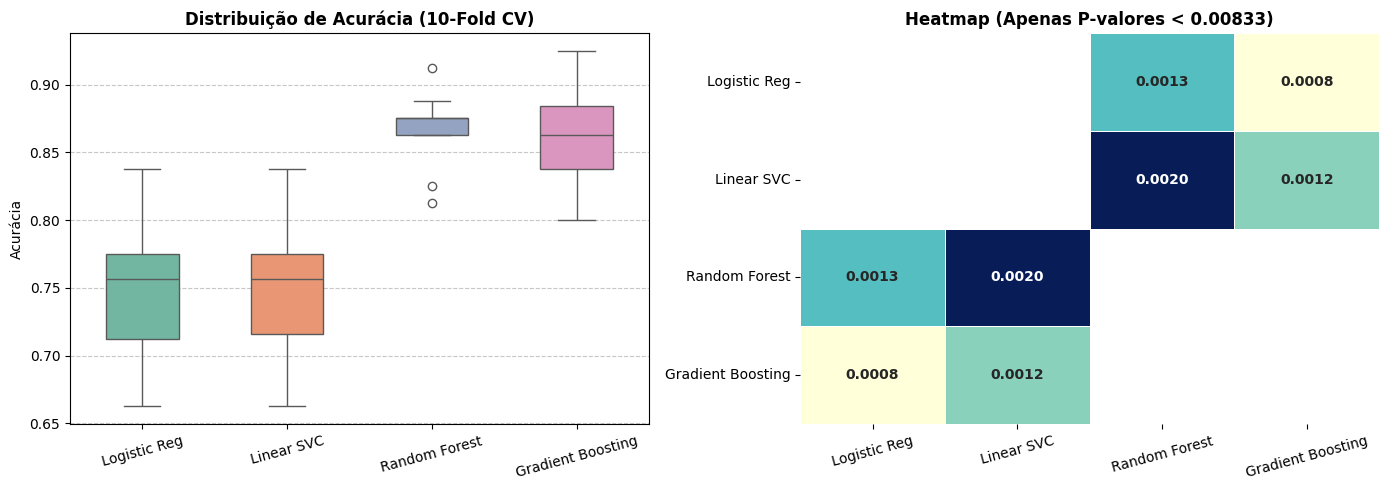

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_results, palette="Set2", width=0.5, ax=ax1)
ax1.set_title("Distribuição de Acurácia (10-Fold CV)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Acurácia")
ax1.tick_params(axis='x', rotation=15)
ax1.grid(axis='y', linestyle='--', alpha=0.7)

mask = df_p_t >= α_bonferroni

sns.heatmap(df_p_t, annot=True, fmt=".4f", cmap="YlGnBu",
            mask=mask, cbar=False, linewidths=.5, ax=ax2,
            annot_kws={"weight": "bold"})

ax2.set_title(f"Heatmap (Apenas P-valores < {α_bonferroni:.5f})", fontsize=12, fontweight='bold')
ax2.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

<font size=3>
    
1. **A Visão do Boxplot (esquerda):** Ele nos mostra o comportamento bruto. Podemos ver quem teve a maior mediana e quem oscilou mais (caixas largas). No entanto, lembre-se de que o Boxplot esconde o *pareamento* (o fato de os modelos terem competido nas exatas mesmas dobras).

2. **Os Heatmaps de Significância (centro e direita):** Aqui está a prova estatística. As células coloridas indicam vitórias/derrotas diretas que foram significativas sob o rigoroso limite de Bonferroni ($\alpha \approx 0.0083$). As células que ficaram **brancas/vazias** indicam "empate técnico".



#### **1.2.2 Teste de Friedman:**
<font size=3>

Para mitigar esse problema, adotamos uma abordagem em duas etapas: primeiro, aplicamos um **Teste Omnibus** (global), que verifica se existe *qualquer* diferença significativa dentro do ecossistema de modelos. Aqui, iremos utilizar o **Teste de Friedman**.
    
Seja $N$ o número de conjuntos de dados independentes e $k$ o número total de modelos em teste. Para cada dataset $i$, os modelos são ordenados do melhor para o pior, atribuindo-se ranks de $1$ a $k$. Em caso de empates, atribui-se a média dos ranks ocupados. Calcula-se o *rank* médio de cada modelo $j$ ao longo de todos os $N$ datasets,
$$
    R_j = \frac{1}{N} \sum_{i=1}^N \text{Rank}_{i,j} \, .
$$

Sob a hipótese nula ($H_0$), todos os algoritmos são equivalentes, o que implica que seus ranks médios deveriam ser idênticos e iguais a $(k+1)/2$. A estatística original de Friedman mensura o desvio dos *ranks* observados em relação a esse valor esperado sob $H_0$,
$$
    \chi_F^2 = \frac{12N}{k(k+1)} \left[\sum_{j=1}^k R_j^2 - \frac{k(k+1)^2}{4} \right] \, .
$$

Embora amplamente utilizada, a aproximação original por Qui-quadrado proposta por Friedman é reconhecidamente **conservadora demais**, apresentando baixo poder estatístico quando o número de datasets $N$ é pequeno. Para corrigir essa distorção, iremos considerar a distribuição $F$ de Snedecor, dada por
$$
    F_F = \frac{(N-1)\chi_F^2}{N(k-1) - \chi_F^2} \, .
$$


In [15]:
# configuração do pipeline de avaliação:
N_datasets = 10
k_models = 3

models = {'M1 (Random Forest)':RandomForestClassifier(n_estimators=50, random_state=42),
          'M2 (Linear SVC)':SVC(kernel='linear', C=1.0),
          'M3 (Logistic Reg)':LogisticRegression(max_iter=1000)}

results = {name:[] for name in models.keys()}

# loop para garantir a independência entre datasets:
for idx in range(N_datasets):
    X, y = make_classification(n_samples=600, n_features=15, n_informative=10, n_classes=2,
                               weights=[0.65, 0.35], flip_y=0.12, random_state=100 + idx)

    for name, model in models.items():
        # extraindo a acurácia média estável obtida via validação cruzada interna de 5 folds:
        score = np.mean(cross_val_score(model, X, y, cv=5, scoring='accuracy'))
        results[name].append(score)

df_experiment = pd.DataFrame(results, index=[f"Dataset_{i+1}" for i in range(N_datasets)])
df_experiment.round(3)

,M1 (Random Forest),M2 (Linear SVC),M3 (Logistic Reg)
Dataset_1,0.812,0.748,0.757
Dataset_2,0.833,0.797,0.780
Dataset_3,0.880,0.880,0.872
Dataset_4,0.830,0.810,0.807
Dataset_5,0.810,0.763,0.738
Dataset_6,0.852,0.815,0.813
Dataset_7,0.873,0.867,0.867
Dataset_8,0.842,0.837,0.845
Dataset_9,0.832,0.843,0.837
Dataset_10,0.795,0.715,0.708


In [16]:
# convertendo os desempenhos em ranks:
df_ranks = df_experiment.rank(axis=1, ascending=False, method='average')
df_ranks

,M1 (Random Forest),M2 (Linear SVC),M3 (Logistic Reg)
Dataset_1,1.0,3.0,2.0
Dataset_2,1.0,2.0,3.0
Dataset_3,1.5,1.5,3.0
Dataset_4,1.0,2.0,3.0
Dataset_5,1.0,2.0,3.0
Dataset_6,1.0,2.0,3.0
Dataset_7,1.0,2.0,3.0
Dataset_8,2.0,3.0,1.0
Dataset_9,3.0,1.0,2.0
Dataset_10,1.0,2.0,3.0


In [17]:
# cálculando o Teste de Friedman com correção:
ranks_mean = df_ranks.mean()

print("Ranks médio globais:")
for mod, rank_med in ranks_mean.items():
    print(f"-> {mod}: {rank_med:.2f}")

# cálculando a estatística Qui-quadrado de Friedman original:
squared_sum_ranks = np.sum(ranks_mean**2)
adjustment = (k_models*(k_models + 1)**2)/4
chi2_friedman = (12*N_datasets/(k_models*(k_models + 1)))*(squared_sum_ranks - adjustment)

# aplicação da correção para a Estatística F:
F_iman_davenport = ((N_datasets - 1)*chi2_friedman)/((N_datasets*(k_models - 1)) - chi2_friedman)

# Graus de liberdade e p-valor via distribuição F de Snedecor
df1 = k_models - 1
df2 = (k_models - 1) * (N_datasets - 1)
p_value_f = 1 - stats.f.cdf(F_iman_davenport, df1, df2)

print(f"\nEstatística Qui-quadrado de Friedman original: {chi2_friedman:.4f}")
print(f"Estatística F corrigida:                       {F_iman_davenport:.4f}")
print(f"p-valor global (Omnibus) calculado:            {p_value_f:.6f}\n")


Ranks médio globais:
-> M1 (Random Forest): 1.35
-> M2 (Linear SVC): 2.05
-> M3 (Logistic Reg): 2.60

Estatística Qui-quadrado de Friedman original: 7.8500
Estatística F corrigida:                       5.8148
p-valor global (Omnibus) calculado:            0.011270



#### **1.2.3 Análise Pós-Hoc (Teste de Nemenyi):**
<font size=3>
    
Se o Teste de Friedman rejeitar a hipótese nula global ($p \le \alpha$), sabemos matematicamente que *pelo menos um* modelo difere dos demais. Contudo, o teste omnibus não é capaz de nos apontar quais pares específicos divergem. Para localizar essas discrepâncias sem comprometer o rigor estatístico, avançamos para a segunda etapa: a análise **pós-hoc** através do **Teste de Nemenyi**.

O Teste de Nemenyi realiza comparações par a par entre todos os modelos. O desempenho de dois modelos é declarado estatisticamente diferente se a diferença absoluta entre os seus *ranks* médios ($|R_a - R_b|$) for igual ou superior à **Distância Crítica (*Critical Distance* — CD)**, definida por
$$
    CD = q_\alpha \sqrt{\frac{k(k+1)}{6N}} \, ,
$$
onde o valor crítico $q_\alpha$ provém da distribuição da amplitude estatística estudentizada dividida por $\sqrt{2}$ (cujos valores exatos para o teste bicaudal de Nemenyi encontram-se tabulados na literatura estatística). Se a distância entre dois *ranks* médios ultrapassar o limiar $CD$, rejeita-se a equivalência entre aquele par de modelos.

In [18]:
# execução do teste Pós-Hoc de Nemenyi:
if p_value_f < α:
    print(f"RESULTADO: p-valor ({p_value_f:.4f}) <= α ({α}). Rejeita-se H0.")
    print("Conclusão: Existe uma diferença estatisticamente significativa entre os algoritmos nos datasets avaliados.")

    q_alpha = 2.343 # valor crítico q_alpha tabelado de Nemenyi (para alpha=0.05 e k=3)

    critical_distance = q_alpha*np.sqrt((k_models*(k_models + 1))/(6*N_datasets))

    print(f"Limiar de distância crítica de Nemenyi: {critical_distance:.4f}\n")

    print("Análise de comparação par a par:")

    nomes_modelos = list(models.keys())

    for i in range(k_models):
        for j in range(i + 1, k_models):
            mod1, mod2 = nomes_modelos[i], nomes_modelos[j]
            diff_ranks = np.abs(ranks_mean[mod1] - ranks_mean[mod2])

            if diff_ranks >= critical_distance:
                print(f"-> [{mod1}] vs [{mod2}] | Diferença = {diff_ranks:.2f} >= CD -> SIGNIFICATIVA.")
            else:
                print(f"   [{mod1}] vs [{mod2}] | Diferença = {diff_ranks:.2f} < CD  -> EQUIVALENTES.")

else:
    print(f"RESULTADO OMNIBUS: p-valor ({p_value_f:.6f}) > α ({α}). FALHA EM REJEITAR H0 GLOBAL.")
    print("Conclusão: Não há evidência estatística de qualquer diferença entre os três modelos.")


RESULTADO: p-valor (0.0113) <= α (0.05). Rejeita-se H0.
Conclusão: Existe uma diferença estatisticamente significativa entre os algoritmos nos datasets avaliados.
Limiar de distância crítica de Nemenyi: 1.0478

Análise de comparação par a par:
   [M1 (Random Forest)] vs [M2 (Linear SVC)] | Diferença = 0.70 < CD  -> EQUIVALENTES.
-> [M1 (Random Forest)] vs [M3 (Logistic Reg)] | Diferença = 1.25 >= CD -> SIGNIFICATIVA.
   [M2 (Linear SVC)] vs [M3 (Logistic Reg)] | Diferença = 0.55 < CD  -> EQUIVALENTES.


### **1.3 Visualização de resultados:**
<font size=3>
    
Tabelas numéricas são precisas, mas muitas vezes falham em transmitir a "história" completa dos dados. Na comparação de modelos, precisamos visualizar dois aspectos fundamentais:

1.  **Estabilidade:** O modelo é consistente ou varia muito dependendo do *dataset* de teste? (Visualizado via **Boxplots**)
2.  **Significância:** A diferença entre os rankings é estatisticamente válida? (Visualizado via **CD Diagrams**)

#### **1.3.1. Análise de estabilidade (Boxplots):**
<font size=3>
    
O Boxplot (diagrama de caixa) nos permite observar a dispersão da acurácia.
  * **Caixa curta:** baixa variância (modelo estável).
  * **Caixa longa:** alta variância (modelo instável/sensível aos dados).
  * **Linha central:** mediana (mais robusta que a média para distribuições não-normais).
    

In [19]:
#pip install scikit_posthocs

In [20]:
import scikit_posthocs as sp

ModuleNotFoundError: No module named 'scikit_posthocs'

In [ ]:
sns.set_style("whitegrid")

plt.figure(figsize=(8, 5))
plt.title("Distribuição da Acurácia por Modelo", fontsize=14)

sns.boxplot(data=df_experiment, palette="Set3")
sns.stripplot(data=df_experiment, color=".25", size=4, alpha=0.6)

means = df_experiment.mean()

plt.scatter(range(len(means)), means, marker='D', color='red', s=30, label='Média', zorder=10)

plt.ylabel("Acurácia")
plt.legend()
plt.show()

#### **1.3.2 Diagrama de Diferença Crítica:**
<font size=3>
    
O **Diagrama de Diferença Crítica** (*Critical Difference Diagram*) é excelente para visualizar testes de Nemenyi em trabalhos científicos.

In [ ]:
# executa o teste de Nemenyi usando os dados de df_experiment:
nemenyi_results = sp.posthoc_nemenyi_friedman(df_experiment)

plt.figure(figsize=(10, 4))
plt.title("Diagrama de Diferença Crítica (Nemenyi, α = 0.05)", y=1.2, fontsize=14, fontweight='bold')

sp.critical_difference_diagram(ranks_mean, nemenyi_results)

plt.xlim(0.9, 3.1)
plt.show()

<font size=3>

**Como ler este gráfico:**
1. **Eixo Horizontal:** Representa o **ranking médio** dos modelos.
2. **Linhas horizontais grossas:** Conectam grupos de modelos que **não são estatisticamente diferentes** entre si.
    * Se uma barra conecta o Modelo A e o Modelo B, significa que eles estão em "empate técnico" estatístico.
    * Se não há barra conectando dois modelos, a diferença entre eles é **significativa** (p-valor \< 0.05).

## **2. Decomposição Viés-Variância:**
<font size=3>
    
A decomposição viés-variância busca entender **por que um modelo erra**: se por simplificações excessivas (**viés alto**) ou por instabilidade frente aos dados de treino (**variância alta**). Essa análise é particularmente útil para guiar a escolha de modelos e ajustar sua complexidade.

<font size=3><center>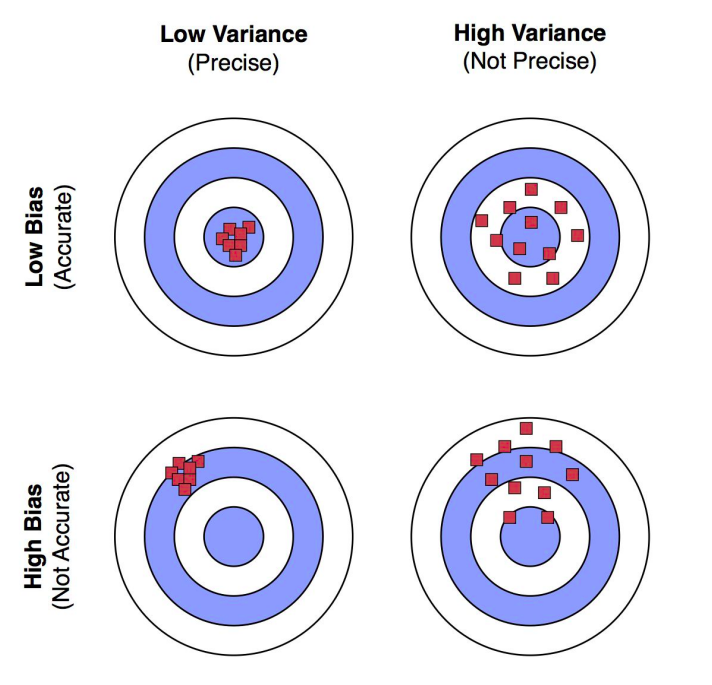</center>

<font size=3>

Para uma tarefa de **classificação binária**, podemos avaliar a previsão **probabilística** dos modelos, tratando-a como um **problema de regressão** sobre a variável indicadora da classe correta. A decomposição do erro quadrático médio (MSE) se mantém válida:
$$
    \mathbb{E}[(y - \hat{f}(x))^2] = \underbrace{[\mathbb{E}[\hat{f}(x)] - y]^2}_{\text{Viés}^2} + \underbrace{\mathbb{E}[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2]}_{\text{Variância}} + \text{Ruído irredutível} \, ,
$$
onde:
* $y \in \{0, 1\}$ é a classe real;
* $\hat{f}(x)$ é a probabilidade prevista da classe 1;
* $y$ é o valor verdadeiro esperado;

* **Viés²:** Mede o quão distante a predição média do modelo está do valor real. Modelos muito rígidos (como regressões lineares simples) não conseguem capturar padrões complexos, gerando alto viés (*underfitting*);

* **Variância:** Mede a sensibilidade do modelo às flutuações do conjunto de treinamento. Modelos excessivamente complexos (como árvores de decisão profundas) memorizam ruídos do treino e mudam drasticamente de predição se alterarmos um único dado, gerando alta variância (*overfitting*).

<br>

Abaixo, vamos comparar **Naive Bayes** (modelo de alto viés, baixa variância) com **Árvore de Decisão** (baixo viés, alta variância), usando um conjunto sintético.


In [ ]:
from sklearn.base import clone
from sklearn.model_selection import train_test_split

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

In [ ]:
# simulando os dados:
X, y = make_classification(n_samples=1000, n_features=20, n_informative=15,
                           n_classes=2, weights=[0.5, 0.5], random_state=42)

# definindo os dados de teste:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
def vies_variancia(model, X_train, y_train, X_test, y_test, n_iterations=100):

    y_pred_probs = []

    for _ in range(n_iterations):
        # amostragem bootstrap:
        index_bootstrap = np.random.choice(len(X_train), size=len(X_train), replace=True)
        X_train_boot, y_train_boot = X_train[index_bootstrap], y_train[index_bootstrap]

        # clona o estimador para iniciar um treinamento limpo mantendo os hiperparâmetros:
        model = clone(model)
        model.fit(X_train_boot, y_train_boot)

        # guarda a probabilidade prevista da classe positiva (classe 1):
        y_pred_probs.append(model.predict_proba(X_test)[:, 1])

    y_pred_probs = np.array(y_pred_probs)

    mean_pred = np.mean(y_pred_probs, axis=0)

    bias2 = np.mean((mean_pred - y_test)**2)
    variance = np.mean(np.var(y_pred_probs, axis=0))

    return bias2, variance




In [ ]:
# Instanciando dois modelos em extremos opostos de complexidade
models = {'Árvore Rasa (Underfitting)': DecisionTreeClassifier(max_depth=2, random_state=42),
          'Árvore Profunda (Overfitting)': DecisionTreeClassifier(max_depth=None, random_state=42),
          'Naive Bayes (Assunção Forte)': GaussianNB()}

results_decomposition = {}

print("Executando simulação de Viés-Variância (100 rodadas de Bootstrap)...\n")
for nome, modelo in models.items():

    b2, var = vies_variancia(modelo, X_train, y_train, X_test, y_test)

    results_decomposition[nome] = {'Viés²': b2, 'Variância': var, 'Erro Total Estimado': b2 + var}
    print(f"{nome}: Viés² = {b2:.3f}, Variância = {var:.3f}")


In [ ]:
df_results = pd.DataFrame(results_decomposition).T

df_results[['Viés²', 'Variância']].plot(kind='bar', stacked=True, figsize=(10, 6), color=['tab:blue','tab:red'], alpha=0.6)

plt.title("Decomposição Viés-Variância por Arquitetura de Modelo", fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Magnitude do Erro (Probabilidades)", fontsize=12)
plt.xticks(rotation=0, fontsize=11)
plt.legend(loc='upper right', fontsize=11)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

<font size=3>
<br>
    
O gráfico em barras empilhadas gerado pelo código nos fornece a natureza do erro de cada algoritmo:
1. **A Árvore Rasa (_underfitting_):** Possui uma barra vermelha muito larga. Como sua profundidade é limitada a 2, ela tem uma capacidade de representação (capacidade teórica) muito baixa. Ela cria premissas fortes e errôneas sobre a complexidade dos dados (Alto Viés).

2. **A Árvore Profunda (_overfitting_):** Apresenta o comportamento inverso. Sua barra vermelha é menor porque, ao não ter limite de profundidade, ela consegue se contorcer matematicamente para encontrar os padrões perfeitos e reduzir o viés. Contudo, a barra azul "explode". Ela memorizou os ruídos específicos de cada amostra Bootstrap, tornando suas predições altamente instáveis (Alta Variância) a cada nova iteração.

3. **O Naive Bayes:** Apresenta uma barra vermelha alta e uma barra azul quase invisível. Como ele assume "ingenuamente" que todas as variáveis do *dataset* são totalmente independentes entre si, ele é incapaz de mapear as interações complexas dos dados (**Alto Viés**). Por outro lado, como seu treinamento se resume a calcular médias e frequências estatísticas diretas, ele é completamente blindado contra ruídos. Mudar os dados no Bootstrap não altera suas tabelas de probabilidade, garantindo uma estabilidade extrema (**baixíssima Variância**).

>* Se o diagnóstico do seu modelo em produção acusa **Alto Viés**, aumentar o tamanho do banco de dados de treino não ajudará em nada. Você precisa de um modelo com maior capacidade de parametrização (ex: trocar Regressão Linear por Redes Neurais).
>
>* Se o diagnóstico acusa **Alta Variância**, você deve aplicar técnicas de regularização (ex: poda de árvores), usar métodos de *Ensemble* (como Random Forest, que ataca especificamente a variância tirando a média de múltiplas árvores) ou coletar mais dados de treinamento para estabilizar a função aprendida.


## __Referências:__
<font size=3>

- **(9.4 - 9.5)**: K. Faceli, _Inteligência artificial: uma abordagem de aprendizado de máquina_. Grupo Gen - LTC, 2011.
  